In [2]:
import time                      #cronometrare il tempo
import matplotlib.pyplot as plt  #graficare il risultato

import tensorflow as tf     #libreria di tensorflow

In [3]:
#percorso del datasets
path = "kagglehub"

dir_training = path+"/seg_train"  #percorso dati TRAINING
dir_validation = path+"/seg_test" #percorso dati TEST

In [4]:
#inizializzazione dati
IMG_SIZE = (150, 150)  #dim. immagine
BATCH_SIZE = 64        #dim. batch
EPOCH = 30             #n. epoch
seed = 67              #seed

#trasformazione per le immagini destinati al training
training_data = tf.keras.utils.image_dataset_from_directory(dir_training,          #posizione cartella training
                                                            image_size=IMG_SIZE,   #impostazione grandezza immagine
                                                            batch_size=BATCH_SIZE, #divisione di immagini in porzioni di dim. BATCH_SIZE=64
                                                            seed = seed
                                                           )

#trasformazione per le immagini destinati al test
validation_data = tf.keras.utils.image_dataset_from_directory(dir_validation,      #posizione cartella test
                                                            image_size=IMG_SIZE,   #impostazione grandezza immagine
                                                            batch_size=BATCH_SIZE, #divisione di immagini in porzioni di dim. BATCH_SIZE=64
                                                            seed = seed
                                                            )

classi = training_data.class_names      #lista di tutti tipi di classificazione
print("classificazione tipi: ", classi)

Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.
classificazione tipi:  ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [5]:
print(tf.config.list_physical_devices("GPU"))

[]


In [6]:
#ottimizza il carimento delle immagini
AUTOTUNE = tf.data.AUTOTUNE #viene assegnato il valore del buffer in automatico per contenere le immagini

#cache() mantiene in memoria le immagini già caricate e preprocessate (per evitare la rileggere i dati)
#prefetch() prepara in anticipo i batch successivi mentre il modello elabora il batch attuale
training_data = training_data.cache().prefetch(buffer_size=AUTOTUNE)
validation_data = validation_data.cache().prefetch(buffer_size=AUTOTUNE)

In [7]:
#rete
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(150,150,3)),  #strato di input 150x150x3 dim. dell'immagine 150x150 e x3 è il canale RGB
    tf.keras.layers.RandomFlip('horizontal'),  #gira l'immagine attorno la linea orizzonatale casualmente
    tf.keras.layers.RandomRotation(0.2),       #rotazione dell'immagine 1/5 di 360° casualmente
    tf.keras.layers.Rescaling(1./255),         #modifica la scala dell'immagine da 1-255 a 0-1 (migliora le perfomance)

    

    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    #Conv2D() viene creato una feature map da 32x148x148 
    #con la funzione di attivazione relu
    tf.keras.layers.MaxPooling2D(),
    #MaxPooling2D() dimezza la feature map e da 32x74x74
    
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    #Conv2D() viene creato una feature map da 64x72x72 
    #con la funzione di attivazione relu
    tf.keras.layers.MaxPooling2D(),
    #Maxpooling2D() dimezza la feature map e da 32x36x36
    
    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    #Conv2D() viene creato una feature map da 128x34x34
    #con la funzione di attivazione relu
    tf.keras.layers.MaxPooling2D(),
    #Maxpooling2D() dimezza la feature map e da 128x17x17
    
    tf.keras.layers.Flatten(),                                #trasforma la matrice in un vettore monodimensionale
    tf.keras.layers.Dense(64, activation='relu'),             #strato di attivazione relu per elaborare le feature maps
    tf.keras.layers.Dropout(0.3),                             #disattiva il 30% dei neurone dello strato precedente (evitare l'overfitting)
    tf.keras.layers.Dense(len(classi), activation="softmax")  #strato che determina la classificazione
])
model.summary() #mostra la struttura feedfoward della rete

model.compile(optimizer='adam',                       #il tipo di ottimizzatore per la gradient descent
              loss="sparse_categorical_crossentropy", #la funzione di costo
              metrics=['accuracy'])       #durante il training e il test viene mostrato la percentuale di accuracy

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 150, 150, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,367,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,461,190 (9.39 MB)

 Trainable params: 2,461,190 (9.39 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
start_time = time.time() #cronometra il tempo

#viene passato nel parametro il training, validation e epochs
risu = model.fit(training_data, validation_data=validation_data, epochs=EPOCH)  #allena il modello

print("training time: ", time.time() - start_time)

Epoch 1/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 178s 791ms/step - accuracy: 0.5110 - loss: 1.2426 - val_accuracy: 0.6187 - val_loss: 1.0262
Epoch 2/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 158s 715ms/step - accuracy: 0.6082 - loss: 1.0305 - val_accuracy: 0.6360 - val_loss: 0.9606
Epoch 3/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 160s 727ms/step - accuracy: 0.6437 - loss: 0.9513 - val_accuracy: 0.7380 - val_loss: 0.7768
Epoch 4/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 157s 715ms/step - accuracy: 0.6732 - loss: 0.8934 - val_accuracy: 0.7157 - val_loss: 0.7674
Epoch 5/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 206s 734ms/step - accuracy: 0.6933 - loss: 0.8470 - val_accuracy: 0.7210 - val_loss: 0.7731
Epoch 6/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 161s 732ms/step - accuracy: 0.7105 - loss: 0.8033 - val_accuracy: 0.7570 - val_loss: 0.7083
Epoch 7/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 181s 821ms/step - accuracy: 0.7220 - loss: 0.7738 - val_accuracy: 0.7213 - val_loss: 0.7941
Epoch 8/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 168s 765ms/step - accuracy: 0.7310 -

In [12]:
#salva il modello
model.save('Modello/model_Tensorflow.keras')

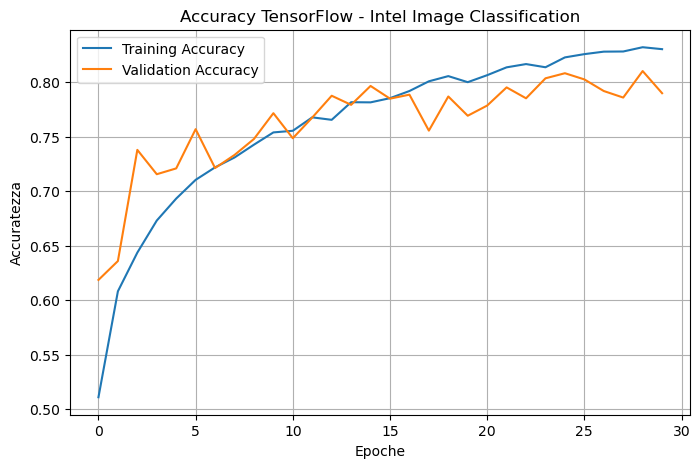

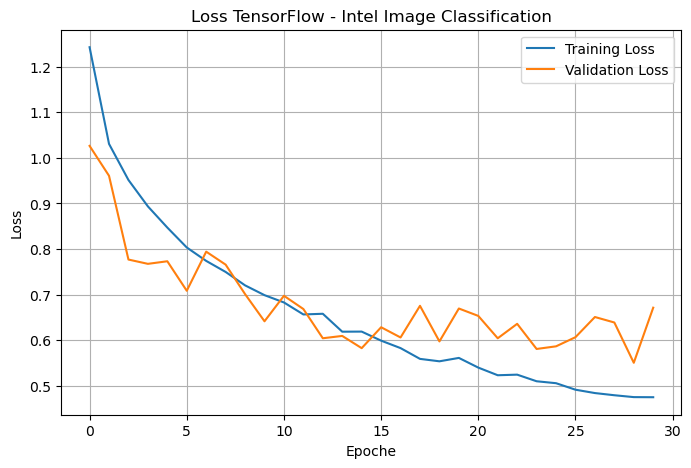

In [13]:
# Accuracy
plt.figure(figsize=(8,5))

plt.plot(risu.history['accuracy'], label='Training Accuracy')
plt.plot(risu.history['val_accuracy'], label='Validation Accuracy')

plt.title('Accuracy TensorFlow - Intel Image Classification')
plt.xlabel('Epoche')
plt.ylabel('Accuratezza')

plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(8,5))

plt.plot(risu.history['loss'], label='Training Loss')
plt.plot(risu.history['val_loss'], label='Validation Loss')

plt.title('Loss TensorFlow - Intel Image Classification')
plt.xlabel('Epoche')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)
plt.show()